In [40]:
import pandas as pd
import numpy as np
import joblib
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr

import matplotlib.pyplot as plt

In [41]:
features = pd.read_csv("../data/customer_features_lowie1.csv")
train = pd.read_csv("../data/customer_clv_train.csv")

df = train.merge(features, on="cust_id", how="left")

In [42]:
churn_lgb = joblib.load("../models/lowie1_churn_lgb_model.pkl")
churn_xgb = joblib.load("../models/lowie1_churn_xgb_model.pkl")
churn_cat = joblib.load("../models/lowie1_churn_cat_model.pkl")

iso_lgb = joblib.load("../models/lowie1_iso_lgb.pkl")
iso_xgb = joblib.load("../models/lowie1_iso_xgb.pkl")
iso_cat = joblib.load("../models/lowie1_iso_cat.pkl")

def predict_churn_proba(X):
    p_lgb = iso_lgb.transform(churn_lgb.predict_proba(X)[:, 1])
    p_xgb = iso_xgb.transform(churn_xgb.predict_proba(X)[:, 1])
    p_cat = iso_cat.transform(churn_cat.predict_proba(X)[:, 1])
    return (p_lgb + p_xgb + p_cat) / 3

In [43]:
feature_cols = joblib.load("../models/lowie1_feature_columns.pkl")

In [44]:
# 60% train, 20% threshold optimalisatie, 20% finale validatie
df_trainval, df_val = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_thresh = train_test_split(df_trainval, test_size=0.25, random_state=42)
print(f"Train: {len(df_train)}  Thresh: {len(df_thresh)}  Val: {len(df_val)}")

p_return_val = predict_churn_proba(df_val[feature_cols])

df_return_train = df_train[df_train["revenue_2018_2019"] > 0].copy()
X_rev_train = df_return_train[feature_cols]
y_rev_train = np.log1p(df_return_train["revenue_2018_2019"].values)

Train: 69954  Thresh: 23318  Val: 23319


# LightGBM

In [45]:
lgb_model = lgb.LGBMRegressor(
    objective="mae",
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=64,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_rev_train, y_rev_train)

,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.03
,n_estimators,1200
,subsample_for_bin,200000
,objective,'mae'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,30


# XGBoost

In [46]:
xgb_model = xgb.XGBRegressor(
    objective="reg:absoluteerror",
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_rev_train, y_rev_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:absoluteerror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

# CatBoost

In [47]:
cat_model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.03,
    depth=6,
    loss_function="MAE",
    verbose=False,
    random_state=42
)

cat_model.fit(X_rev_train, y_rev_train)

CatBoostRegressor(depth=6, iterations=800, learning_rate=0.03, loss_function='MAE', random_state=42, verbose=False)


# Comparison & Threshold Optimazation

In [48]:
p_return_thresh = predict_churn_proba(df_thresh[feature_cols])

best_overall_mae = 1000
best_threshold = 0
rev_model = None
best_model_name = None

for name, model in [("LightGBM", lgb_model), ("XGBoost", xgb_model), 
                    ("CatBoost", cat_model)]:
    
    # Threshold optimalisatie op df_thresh — apart van df_val
    log_preds_thresh = model.predict(df_thresh[feature_cols])
    rev_preds_thresh = np.expm1(log_preds_thresh)
    
    best_corr, best_t, best_mae = -1, 0, 1000
    for t in [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 
              0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]:
        preds = np.where(p_return_thresh < t, 0, p_return_thresh * rev_preds_thresh)
        mae = mean_absolute_error(df_thresh["revenue_2018_2019"], preds)
        corr, _ = spearmanr(df_thresh["revenue_2018_2019"], preds)
        if mae < best_mae:
            best_corr, best_t, best_mae = corr, t, mae
    
    print(f"{name} - Thresh MAE: {best_mae:.2f}  Spearman: {best_corr:.4f}  Threshold: {best_t:.2f}")
    
    if best_mae < best_overall_mae:
        best_overall_mae = best_mae
        best_threshold = best_t
        rev_model = model
        best_model_name = name

print(f"\nBest model: {best_model_name}  Threshold: {best_threshold:.2f}")

# Finale validatie MAE op held-out df_val — enkel voor rapportage
log_preds_val = rev_model.predict(df_val[feature_cols])
rev_preds_val = np.expm1(log_preds_val)
final_val_preds = np.where(p_return_val < best_threshold, 0, p_return_val * rev_preds_val)
val_mae = mean_absolute_error(df_val["revenue_2018_2019"], final_val_preds)
val_corr, _ = spearmanr(df_val["revenue_2018_2019"], final_val_preds)
print(f"\nFinale MAE op held-out validatieset: {val_mae:.2f}  Spearman: {val_corr:.4f}")

LightGBM - Thresh MAE: 61.99  Spearman: 0.3986  Threshold: 0.55
XGBoost - Thresh MAE: 61.94  Spearman: 0.3992  Threshold: 0.55
CatBoost - Thresh MAE: 61.95  Spearman: 0.3992  Threshold: 0.55

Best model: XGBoost  Threshold: 0.55

Finale MAE op held-out validatieset: 62.52  Spearman: 0.4020


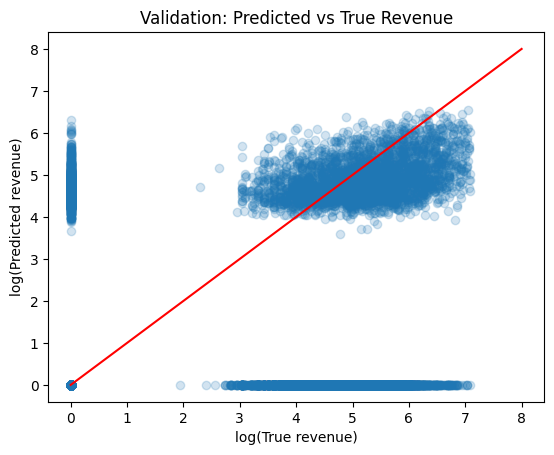

In [49]:
val_final_pred = np.where(
    p_return_val < best_threshold,
    0,
    p_return_val * np.expm1(rev_model.predict(df_val[feature_cols]))
)

plt.scatter(
    np.log1p(df_val["revenue_2018_2019"]),
    np.log1p(val_final_pred),
    alpha=0.2
)
plt.xlabel("log(True revenue)")
plt.ylabel("log(Predicted revenue)")
plt.plot([0, 8], [0, 8], "r")
plt.title("Validation: Predicted vs True Revenue")
plt.show()

In [50]:
# === Retrain best revenue model on full trainval (80% of the data) ===
# Threshold and model choice already are fixed on df_thresh
# Now retrain on more data for better generalization on submission

df_return_trainval = df_trainval[df_trainval["revenue_2018_2019"] > 0].copy()
X_rev_full = df_return_trainval[feature_cols]
y_rev_full = np.log1p(df_return_trainval["revenue_2018_2019"].values)

print(f"Returners voor retrain: {len(df_return_trainval)} "
      f"(was {len(df_return_train)} op 60%)")

# Retrain with exactly same parameters as the winning model
if best_model_name == "LightGBM":
    rev_model_final = lgb.LGBMRegressor(
        **rev_model.get_params(), random_state=42, verbose=-1
    )
elif best_model_name == "XGBoost":
    params = rev_model.get_params()
    params.pop("random_state", None)
    params.pop("verbosity", None)
    rev_model_final = xgb.XGBRegressor(
        **params, random_state=42, verbosity=0
    )
elif best_model_name == "CatBoost":
    params = rev_model.get_params()
    params.pop("random_seed", None)
    params.pop("random_state", None)
    params.pop("verbose", None)
    rev_model_final = CatBoostRegressor(
        **params, random_seed=42, verbose=False
    )

rev_model_final.fit(X_rev_full, y_rev_full)

# Verification on val-set - only for info, not for model choice
val_pred_final = np.where(
    p_return_val < best_threshold,
    0,
    p_return_val * np.maximum(
        np.expm1(rev_model_final.predict(df_val[feature_cols])), 0
    )
)
mae_final = np.mean(np.abs(val_pred_final - df_val["revenue_2018_2019"].values))
spearman_final = pd.Series(val_pred_final).corr(
    pd.Series(df_val["revenue_2018_2019"].values), method="spearman"
)
print(f"Val MAE after retrain:     {mae_final:.2f}  (was {val_mae:.2f})")
print(f"Val Spearman after retrain: {spearman_final:.4f}  (was {val_corr:.4f})")
print(f"\nNota: val-set not used for retrain— honest verification.")

Returners voor retrain: 34106 (was 25600 op 60%)


Val MAE after retrain:     62.51  (was 62.52)
Val Spearman after retrain: 0.4015  (was 0.4020)

Nota: val-set not used for retrain— honest verification.


In [51]:
# consistency check: churn proobabilities are stable? 
print(f"\n--- Consistency check ---")
print(f"Average churn probability (val):       {p_return_val.mean():.4f}")
print(f"Fraction predicted as returner:    {(p_return_val > best_threshold).mean():.4f}")
print(f"Actual fraction of returners:      {(df_val['revenue_2018_2019'] > 0).mean():.4f}")


--- Consistency check ---
Average churn probability (val):       0.3650
Fraction predicted as returner:    0.1930
Actual fraction of returners:      0.3667


# Save Revenue Model

In [52]:
joblib.dump(best_threshold,   "../models/lowie1_best_threshold.pkl")
joblib.dump(rev_model_final,  "../models/lowie1_rev_model.pkl")
print(f"Saved: threshold={best_threshold:.2f}, model={best_model_name} (retrained on 80% of data)")

Saved: threshold=0.55, model=XGBoost (retrained on 80% of data)
